## 1. Load data

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')
import torch
import pandas as pd
import scanpy as sc
import sys
import SpatialMuSC
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

os.environ['RPY2_CFFI_MODE'] = 'ABI'
os.environ['R_HOME'] = r'home:\\R\\R-4.5.0'
os.environ['PATH'] = r'home:\\R\\R-4.5.0\\bin;' + os.environ['PATH']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

data_type = 'Spatial-epigenome-transcriptome'
random_seed = 2022
n_clusters = 7

file_fold = 'home:/code_data/Dataset21_human_brain_hipp_raw/Raw data/'


Using device: cuda


In [3]:
adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad(file_fold + 'adata_ATAC.h5ad')

print(adata_omics1)
print(adata_omics2)

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

adata_omics1

AnnData object with n_obs × n_vars = 2500 × 21179
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 2500 × 56614
    obsm: 'spatial'


AnnData object with n_obs × n_vars = 2500 × 21179
    obsm: 'spatial'

## 2. RNA preprocessing

In [4]:
from SpatialMuSC.preprocess import fix_seed, clr_normalize_each_cell, pca, lsi, construct_neighbor_graph

fix_seed(random_seed)
print('Random seed fixed:', random_seed)

Random seed fixed: 2022


In [5]:
sc.pp.filter_genes(adata_omics1, min_cells=10)
print('RNA shape after filter_genes:', adata_omics1.shape)

sc.pp.highly_variable_genes(adata_omics1, flavor='seurat_v3', n_top_genes=3000)
print('Number of highly variable genes:', int(adata_omics1.var['highly_variable'].sum()))

sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
sc.pp.scale(adata_omics1)

adata_omics1_high = adata_omics1[:, adata_omics1.var['highly_variable']]
print('RNA HVG matrix shape:', adata_omics1_high.shape)

adata_omics1.obsm['feat'] = pca(adata_omics1_high, n_comps=60)
print('RNA feature shape:', adata_omics1.obsm['feat'].shape)

RNA shape after filter_genes: (2500, 15192)
Number of highly variable genes: 3000
RNA HVG matrix shape: (2500, 3000)
RNA feature shape: (2500, 60)


## 3. Protein preprocessing

In [6]:
# ATAC preprocessing
adata_omics2 = adata_omics2[adata_omics1.obs_names].copy()
print('ATAC shape after matching RNA cells:', adata_omics2.shape)

if 'X_lsi' not in adata_omics2.obsm.keys():
    sc.pp.highly_variable_genes(adata_omics2, flavor='seurat_v3', n_top_genes=3000)
    lsi(adata_omics2, use_highly_variable=False, n_components=61)

adata_omics2.obsm['feat'] = adata_omics2.obsm['X_lsi'].copy()
print('ATAC feature shape:', adata_omics2.obsm['feat'].shape)

adata_omics2

ATAC shape after matching RNA cells: (2500, 56614)
ATAC feature shape: (2500, 60)


AnnData object with n_obs × n_vars = 2500 × 56614
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'
    obsm: 'spatial', 'X_lsi', 'feat'

## 4. Model training

In [7]:
data = construct_neighbor_graph(adata_omics1, adata_omics2, datatype=data_type)
print('Neighbor graph constructed.')
type(data)

same true： True
Neighbor graph constructed.


dict

In [8]:
from SpatialMuSC.SpatialMuSC_pyG import Train_SpatialMuSC

model = Train_SpatialMuSC(data, datatype=data_type, device=device)
output = model.train()

print(output.keys())

100%|██████████| 1100/1100 [02:55<00:00,  6.29it/s]


dict_keys(['emb_latent_omics1', 'emb_latent_omics2', 'SpatialMuSC'])


In [9]:
adata = adata_omics1.copy()
adata.obsm['emb_latent_omics1'] = output['emb_latent_omics1']
adata.obsm['emb_latent_omics2'] = output['emb_latent_omics2']
adata.obsm['SpatialMuSC'] = output['SpatialMuSC']

print('emb_latent_omics1 shape:', adata.obsm['emb_latent_omics1'].shape)
print('emb_latent_omics2 shape:', adata.obsm['emb_latent_omics2'].shape)
print('SpatialMuSC embedding shape:', adata.obsm['SpatialMuSC'].shape)

emb_latent_omics1 shape: (2500, 64)
emb_latent_omics2 shape: (2500, 64)
SpatialMuSC embedding shape: (2500, 64)


## 5. Clustering

In [10]:
from SpatialMuSC.utils import clustering

clustering(
    adata,
    key='SpatialMuSC',
    add_key='SpatialMuSC',
    n_clusters=n_clusters,
    method='mclust',
    use_pca=True
)

adata.obs['SpatialMuSC'].head()

R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.
  


fitting ...
  |======================================================================| 100%


ACAAGCTAAACGTGAT    3
ACAAGCTAACAAGCTA    1
ACAAGCTACTGTAGCC    1
ACAAGCTAAGTACAAG    1
ACAAGCTAAACAACCA    1
Name: SpatialMuSC, dtype: category
Categories (7, int32): [1, 2, 3, 4, 5, 6, 7]

In [11]:
print('Unique predicted labels:', sorted(adata.obs['SpatialMuSC'].unique()))
print('Number of clusters:', adata.obs['SpatialMuSC'].nunique())

adata.obs['SpatialMuSC'].value_counts().sort_index()

Unique predicted labels: [1, 2, 3, 4, 5, 6, 7]
Number of clusters: 7


SpatialMuSC
1    984
2    106
3    711
4    347
5     85
6    201
7     66
Name: count, dtype: int64

## 6. Evaluation

In [12]:
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score, adjusted_mutual_info_score
from sklearn.metrics import v_measure_score, homogeneity_score, completeness_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score
from metric import jaccard, Dice, F_measure
GT_path = 'home:/code_data/Dataset20_human brain hippocampus/human_hipp_GT.txt'

In [13]:
GT_list = []
with open(GT_path, 'r', encoding='utf-8-sig') as f:
    for line in f:
        line = line.strip()
        if line:
            GT_list.append(int(line))

print("GT length:", len(GT_list))
print("GT label set:", sorted(set(GT_list)))
print("GT min/max:", min(GT_list), max(GT_list))

GT length: 2500
GT label set: [0, 1, 2, 3, 4, 5, 6]
GT min/max: 0 6


In [14]:
pred_list = adata.obs['SpatialMuSC'].tolist()
pred_list = [int(x) for x in pred_list]

print("Pred length:", len(pred_list))
print("Pred label set:", sorted(set(pred_list)))
print("Pred min/max:", min(pred_list), max(pred_list))

Pred length: 2500
Pred label set: [1, 2, 3, 4, 5, 6, 7]
Pred min/max: 1 7


In [15]:
print("GT length   :", len(GT_list))
print("Pred length :", len(pred_list))

if len(GT_list) != len(pred_list):
    raise ValueError("The lengths of the ground-truth labels and predicted labels do not match!")
else:
    print("The lengths of the ground-truth labels and predicted labels match. You can proceed with the evaluation.")

GT length   : 2500
Pred length : 2500
The lengths of the ground-truth labels and predicted labels match. You can proceed with the evaluation.


In [16]:
our_jaccard = jaccard(pred_list, GT_list)
our_dice = Dice(pred_list, GT_list)
our_f_measure = F_measure(pred_list, GT_list)

our_mutual_info = mutual_info_score(GT_list, pred_list)
our_nmi = normalized_mutual_info_score(GT_list, pred_list)
our_ami = adjusted_mutual_info_score(GT_list, pred_list)
our_v = v_measure_score(GT_list, pred_list)
our_homogeneity = homogeneity_score(GT_list, pred_list)
our_completeness = completeness_score(GT_list, pred_list)
our_ari = adjusted_rand_score(GT_list, pred_list)
our_fmi = fowlkes_mallows_score(GT_list, pred_list)

print(f"Our         Jaccard: {our_jaccard:.6f}")
print(f"Our         Dice: {our_dice:.6f}")
print(f"Our         F_measure: {our_f_measure:.6f}")
print(f"Our         Mutual Information: {our_mutual_info:.6f}")
print(f"Our         NMI: {our_nmi:.6f}")
print(f"Our         AMI: {our_ami:.6f}")
print(f"Our         V-measure: {our_v:.6f}")
print(f"Our         Homogeneity: {our_homogeneity:.6f}")
print(f"Our         Completeness: {our_completeness:.6f}")
print(f"Our         ARI: {our_ari:.6f}")
print(f"Our         FMI: {our_fmi:.6f}")

Our         Jaccard: 0.418890
Our         Dice: 0.590447
Our         F_measure: 0.590447
Our         Mutual Information: 0.765570
Our         NMI: 0.466161
Our         AMI: 0.463760
Our         V-measure: 0.466161
Our         Homogeneity: 0.440416
Our         Completeness: 0.495104
Our         ARI: 0.465672
Our         FMI: 0.594633


## 7. Visualization

In [17]:
sc.pp.neighbors(adata, use_rep='SpatialMuSC', n_neighbors=30)
sc.tl.umap(adata)

print('UMAP finished.')

UMAP finished.


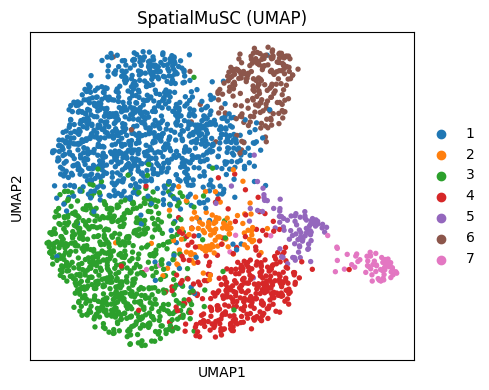

In [18]:
# UMAP only
%matplotlib inline
fig_u, ax_u = plt.subplots(figsize=(5, 4))
sc.pl.umap(
    adata,
    color='SpatialMuSC',
    ax=ax_u,
    title='SpatialMuSC (UMAP)',
    s=60,
    show=False
)
plt.tight_layout()
plt.show()

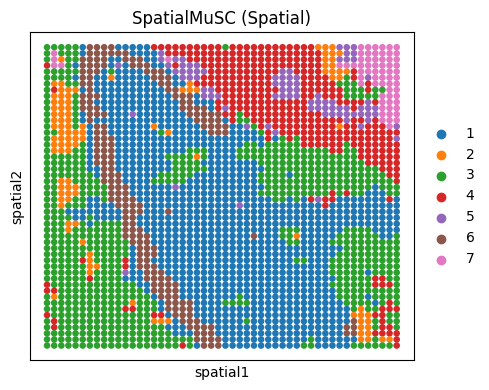

In [19]:
# Spatial only
%matplotlib inline
fig_s, ax_s = plt.subplots(figsize=(5, 4))
sc.pl.embedding(
    adata,
    basis='spatial',
    color='SpatialMuSC',
    ax=ax_s,
    title='SpatialMuSC (Spatial)',
    s=90,
    show=False
)
plt.tight_layout()
plt.show()